
# Stationary response to a softened point mass

This notebook computes the non-axisymmetric gas and stellar density wake produced by a softened point mass in a two-component shearing sheet.

The conventions are the ones used in the point-mass section of the notes:

$$
    y_c = y + 2 A x t,
    \qquad
    k_0(t) = k_x + 2 A t k_{y_c},
    \qquad
    k(t)=\sqrt{k_0^2(t)+k_{y_c}^2}.
$$

A mode with fixed sheared labels \((k_x,k_{y_c})\) corresponds to the physical wavevector

$$
    K_x(t)=k_x+2Atk_{y_c},
    \qquad
    K_y=k_{y_c}.
$$

For a stationary physical wake, the sheared-wave response with $k_x=0$ is relabeled according to

$$
    \delta\widetilde{\Sigma}_i(K_x,k_{y_c})
    =
    S_i\left(k_{y_c},\frac{K_x}{2Ak_{y_c}}\right),
    \qquad i\in\{g,s\}.
$$

The code below therefore solves the master equations only for the $k_x=0$ sheared-wave family and then reconstructs the stationary physical wake by an inverse Fourier transform in $(K_x,k_{y_c})$.


In [1]:

import sys  
from pathlib import Path  
import time  
import numpy as np 
import matplotlib.pyplot as plt  
from matplotlib.ticker import MultipleLocator
from scipy.fft import fftfreq, fftshift, ifft2, rfftfreq, irfft2  # Supplies Fourier grids, centered plotting arrays, and inverse transforms.

# Import a regular-grid interpolator for mapping S_i(k_yc,tau) onto physical Fourier modes.
from scipy.interpolate import RegularGridInterpolator  # Interpolates the sheared-wave response table.

import smplotlib 
from mpl_toolkits.axes_grid1 import make_axes_locatable 
# plt.style.use("./science.mplstyle")  

CODEDIR = Path( 
    "../src/"  # Final part of the absolute project path.
).expanduser() 
if str(CODEDIR) not in sys.path:  
    sys.path.append(str(CODEDIR))  
# from Vlasov_integrators import * 

from dimensionless_to_physical_units import * 

from Vlasov_integrators_thick_disk import * 

from axisymmetric_stability import *  


In [2]:
points_thin_disks = np.array([
    [1.0 / 0.2, 1.0 / 0.7],
    [2.2,  2.2],
    [1.0 / 0.7, 1.0 / 0.2],
])

In [3]:
R = 1.0
Qgas = points_thin_disks[1][1]
Qstars = points_thin_disks[1][0]  
KAPPA = 1.0  # The notebook uses units with kappa = 1.
G = 1.0  # The notebook uses units with G = 1.
hgKO=0.0 
hsKO = 0.0

KCRIT = 1.0  
LAMBDA_CRIT = 2.0 * np.pi /KCRIT
DELTA = 0.05 *  LAMBDA_CRIT
CLOUD_MASS = 1.0 
TAU_MIN = -10.0 * np.pi  
TAU_MAX = 10.0 * np.pi  
N_TAU = 500  
SCALE_MULTIPLIER = 4.0  # The physical domain is [-4,4] times 2*pi/kcrit in each direction.


NX = 1000 
NY = 1000  
KYC_EPS = 1.0e-20  # The map tau = K_x / (2 A k_yc) is singular at k_yc = 0.
PROGRESS_EVERY = 50  # Print progress every 50 k_yc modes.

SAVE_FIGURES = True  
FIGURE_DIR = Path("./Figures")  


## Build the physical and Fourier grids

The inverse transform is performed in physical Fourier variables $(K_x,k_{y_c})$. The arrays named `KX_values` and `KYC_values_half` are therefore not the sheared labels used inside the integrator; they are the physical Fourier grid used in the notebook/code convention

$$
    \delta\Sigma_i(x,y)
    =
    \int dK_x\,dk_{y_c}\,
    \delta\widetilde\Sigma_i(K_x,k_{y_c})
    e^{i(K_xx+k_{y_c}y)} .
$$

With SciPy's `irfft2`, this convention requires the inverse-transform normalization factor

$$
    N_xN_y\Delta K_x\Delta k_y
    =
    \frac{4\pi^2}{dx\,dy}.
$$


In [4]:
# ------------------------------------------------------------
# Real-space grid and Fourier-space grids
# ------------------------------------------------------------

# Compute the physical half-width of the box in both x and y.
# The full box is [-BOX_HALF_WIDTH, BOX_HALF_WIDTH] in each direction.
BOX_HALF_WIDTH = SCALE_MULTIPLIER * 2.0 * np.pi / KCRIT

# Build a periodic x grid without duplicating the endpoint.
# endpoint=False is important because FFTs assume a periodic grid.
x_values = np.linspace(
    -BOX_HALF_WIDTH,
    BOX_HALF_WIDTH,
    NX,
    endpoint=False
)

# Compute the x-grid spacing.
dx = x_values[1] - x_values[0]

# Build a periodic y grid without duplicating the endpoint.
# We use the same physical box size in y as in x.
y_values = np.linspace(
    -BOX_HALF_WIDTH,
    BOX_HALF_WIDTH,
    NY,
    endpoint=False
)

# Compute the y-grid spacing.
dy = y_values[1] - y_values[0]

# Build the physical radial Fourier grid K_x in FFT ordering.
# These are the modes conjugate to x in exp(i K_x x).
KX_values = 2.0 * np.pi * fftfreq(NX, d=dx)

# Build the nonnegative k_yc Fourier grid needed by irfft2.
# These are the modes conjugate to y in exp(i k_yc y).
# We only store k_yc >= 0; irfft2 reconstructs the negative-k_yc modes automatically.
KYC_values_half = 2.0 * np.pi * rfftfreq(NY, d=dy)

# Build a two-dimensional mesh of the physical real-space coordinates.
# The shape is (NX, NY), matching the final real-space wake arrays.
x_mesh, y_mesh = np.meshgrid(
    x_values,
    y_values,
    indexing="ij"
)

# Build a two-dimensional mesh of the half Fourier coordinates.
# The shape is (NX, NY//2 + 1), matching the half-spectrum arrays used by irfft2.
KX_mesh_half, KYC_mesh_half = np.meshgrid(
    KX_values,
    KYC_values_half,
    indexing="ij"
)

# Print the real-space resolution.
print(f"dx = {dx:.6g}, dy = {dy:.6g}")

# Print the Fourier-space resolution.
print(
    f"dKx = {KX_values[1] - KX_values[0]:.6g}, "
    f"dKyc = {KYC_values_half[1] - KYC_values_half[0]:.6g}"
)

# Print useful shape information.
print(f"x_mesh shape = {x_mesh.shape}")
print(f"half Fourier mesh shape = {KX_mesh_half.shape}")

dx = 0.0502655, dy = 0.0502655
dKx = 0.125, dKyc = 0.125
x_mesh shape = (1000, 1000)
half Fourier mesh shape = (1000, 501)



## Convert $(Q_g,Q_s,R)$ to the physical coefficients used by the integrator

The helper function returns the gas and stellar surface densities, the stellar radial velocity dispersion, the gas sound-speed squared, the local rotation frequency, and the Oort constant.


In [5]:
(   _,_, Sigma_g,  
    Sigma_s, 
    sigma_x,  
    cssq, 
    Omega,  
    OortA,  
) = get_physical_densities_and_speed_of_sounds_from_rafikov_dimensionless_variables_for_paper(0,0,Qgas,  
    Qstars, 
    R,
)  

print(f"Sigma_g = {Sigma_g:.6g}")  

print(f"Sigma_s = {Sigma_s:.6g}") 
print(f"sigma_x = {sigma_x:.6g}")  
print(f"c_s = {np.sqrt(cssq):.6g}") 
print(f"Omega = {Omega:.6g}") 
print(f"A = {OortA:.6g}")  


Sigma_g = 0.144686
Sigma_s = 0.135281
sigma_x = 1
c_s = 1
Omega = 0.707107
A = 0.353553



## Solve the sheared-wave response table $S_i(k_{y_c},\tau)$

The solver below computes the response only for the sheared radial label \(k_x=0\). The output arrays are

$$
    S_g(k_{y_c},\tau),
    \qquad
    S_s(k_{y_c},\tau).
$$

These are later relabeled as stationary physical Fourier amplitudes using $K_x=2Ak_{y_c}\tau$.


In [6]:
# ------------------------------------------------------------
# Shearing-wave time grid
# ------------------------------------------------------------

# Build the tau grid used by the Volterra integrator.
tau_values = np.linspace(TAU_MIN, TAU_MAX, N_TAU)


# ------------------------------------------------------------
# Solve S_g(k_yc, tau) and S_s(k_yc, tau)
# ------------------------------------------------------------

def solve_sheared_response_table(
    kyc_values_input,
    tau_values_input,
    Sigma_g_input,
    Sigma_s_input,
    sigma_x_input,
    cssq_input,
    Omega_input,
    OortA_input,
    hg,
    hs,
    delta_input,
    cloud_mass_input,
    progress_every=50,
):
    """
    Solve the kx = 0 sheared-wave response problem for each k_yc.

    This returns the response functions

        S_g(k_yc, tau)
        S_s(k_yc, tau)

    where these are the gas and stellar surface-density responses.

    We only need k_yc >= 0 for the irfft2 reconstruction. The k_yc = 0
    mode is excluded because the map

        tau = K_x / (2 A k_yc)

    is singular there.

    Parameters
    ----------
    kyc_values_input : array
        Nonnegative k_yc values, usually from rfftfreq.

    tau_values_input : array
        Time grid for the Volterra solve.

    Sigma_g_input, Sigma_s_input : float
        Background gas and stellar surface densities.

    sigma_x_input : float
        Stellar radial velocity dispersion.

    cssq_input : float
        Gas sound speed squared.

    Omega_input : float
        Local rotation frequency.

    OortA_input : float
        Oort A constant.

    hg, hs : float
        Dimensionless Kim-Ostriker thickness parameters.

    delta_input : float
        Softening length of the cloud.

    cloud_mass_input : float
        Cloud mass. The response scales linearly with this value.

    progress_every : int
        Print progress every this many k_yc modes.

    Returns
    -------
    response_tau_values : array
        Tau values associated with the returned response arrays.

    S_stars : ndarray
        Stellar response table with shape
        (len(kyc_values_input), len(response_tau_values)).

    S_gas : ndarray
        Gas response table with shape
        (len(kyc_values_input), len(response_tau_values)).
    """

    # The original integrator returns responses on tau_values[1:].
    response_tau_values = tau_values_input[1:]

    # Allocate the stellar response table S_s(k_yc, tau).
    # We store real values because the amplitudes produced by this solver are real.
    S_stars = np.zeros(
        (len(kyc_values_input), len(response_tau_values)),
        dtype=np.float64,
    )

    # Allocate the gas response table S_g(k_yc, tau).
    S_gas = np.zeros(
        (len(kyc_values_input), len(response_tau_values)),
        dtype=np.float64,
    )

    # Convert the dimensionless Kim-Ostriker thickness parameters into the
    # physical scale-height variables expected by the integrator.
    Hg_input = hg * np.sqrt(cssq_input) / KAPPA
    Hs_input = hs * sigma_x_input / KAPPA

    # Start a timer for progress reporting.
    start_time = time.time()

    # Loop over the nonnegative k_yc modes.
    for mode_index, kyc_value in enumerate(kyc_values_input):

        # Print progress occasionally.
        if mode_index % progress_every == 0:
            elapsed = time.time() - start_time
            print(
                f"mode {mode_index:5d} / {len(kyc_values_input):5d}, "
                f"k_yc = {kyc_value:.6e}, "
                f"elapsed = {elapsed:.2f} s"
            )

        # Skip k_yc = 0 because the point-mass wake reconstruction uses
        # tau = K_x / (2 A k_yc), which is singular at k_yc = 0.
        if np.abs(kyc_value) < KYC_EPS:
            continue

        # Solve the kx = 0 sheared-wave problem for this k_yc.
        sim = Gas_plus_stars_integrator(
            kx=0.0,
            kyc=kyc_value,
            Sigma_g=Sigma_g_input,
            Sigma_s=Sigma_s_input,
            kappa=KAPPA,
            Omega0=Omega_input,
            sigma_x=sigma_x_input,
            cssq=cssq_input,
            Hg=Hg_input,
            Hs=Hs_input,
            G=G,
        )

        # Evolve the forced master equation.
        results = sim.solve(
            tau_values_input,
            fext_params={
                "delta": delta_input,
                "amplitude": cloud_mass_input,
            },
            impulse_params={
                "t_0": 0.0,
                "Sigma_impluse": 0.0,
            },
        )

        # Extract the stellar surface-density response.
        stellar_surface_density = sim.get_stellar_surface_density(
            results,
            tau_values_input,
        )

        # Extract the gas surface-density response.
        gas_surface_density = sim.get_gas_surface_density(
            results,
            tau_values_input,
        )

        # Sanity check: the integrator should return len(tau_values)-1 samples.
        if len(stellar_surface_density) != len(response_tau_values):
            raise ValueError(
                "Unexpected stellar response length: "
                f"len(stellar_surface_density) = {len(stellar_surface_density)}, "
                f"len(response_tau_values) = {len(response_tau_values)}"
            )

        if len(gas_surface_density) != len(response_tau_values):
            raise ValueError(
                "Unexpected gas response length: "
                f"len(gas_surface_density) = {len(gas_surface_density)}, "
                f"len(response_tau_values) = {len(response_tau_values)}"
            )

        # Store the stellar response. The cloud mass was passed through
        # fext_params["amplitude"], so do not multiply by cloud_mass_input again.
        S_stars[mode_index, :] = np.real(
            stellar_surface_density
        )

        # Store the gas response. The cloud mass was passed through
        # fext_params["amplitude"], so do not multiply by cloud_mass_input again.
        S_gas[mode_index, :] = np.real(
            gas_surface_density
        )

    return response_tau_values, S_stars, S_gas

In [7]:
response_tau_values, S_stars_half, S_gas_half = solve_sheared_response_table(
    kyc_values_input=KYC_values_half,
    tau_values_input=tau_values,
    Sigma_g_input=Sigma_g,
    Sigma_s_input=Sigma_s,
    sigma_x_input=sigma_x,
    cssq_input=cssq,
    Omega_input=Omega,
    OortA_input=OortA,
    hg=hgKO,
    hs=hsKO,
    delta_input=DELTA,
    cloud_mass_input=CLOUD_MASS,
    progress_every=PROGRESS_EVERY,
)

mode     0 /   501, k_yc = 0.000000e+00, elapsed = 0.00 s


mode    50 /   501, k_yc = 6.250000e+00, elapsed = 7.16 s


mode   100 /   501, k_yc = 1.250000e+01, elapsed = 11.09 s


mode   150 /   501, k_yc = 1.875000e+01, elapsed = 15.06 s


mode   200 /   501, k_yc = 2.500000e+01, elapsed = 19.47 s


...

mode   300 /   501, k_yc = 3.750000e+01, elapsed = 27.23 s


mode   350 /   501, k_yc = 4.375000e+01, elapsed = 31.07 s


mode   400 /   501, k_yc = 5.000000e+01, elapsed = 34.73 s


mode   450 /   501, k_yc = 5.625000e+01, elapsed = 38.49 s


mode   500 /   501, k_yc = 6.250000e+01, elapsed = 42.18 s



## Interpolate $S_i(k_{y_c},\tau)$

The response table is sampled on the FFT-ordered `KYC_values` array. `RegularGridInterpolator` expects monotonic axes, so we use `fftshift` to reorder the $k_{y_c}$ axis from negative to positive values before building the interpolators.


In [8]:
# ------------------------------------------------------------
# Response interpolation helpers
# ------------------------------------------------------------

def interpolate_response_in_tau(
    tau_needed,
    response_tau_values,
    response_values,
):
    """
    Interpolate one response curve S_i(k_yc, tau) onto requested tau values.

    Parameters
    ----------
    tau_needed : array
        The tau values requested by the physical Fourier mapping,

            tau = K_x / (2 A k_yc).

    response_tau_values : array
        The tau grid on which the sheared-wave response was computed.

    response_values : array
        The response values S_i(k_yc, tau) for one fixed k_yc.

    Returns
    -------
    interpolated_values : array
        The response evaluated at tau_needed.

    Notes
    -----
    Values outside the computed tau range are set to zero.
    """

    return np.interp(
        tau_needed,
        response_tau_values,
        response_values,
        left=0.0,
        right=0.0,
    )


## Relabel the sheared-wave response as a stationary physical Fourier amplitude

For each physical Fourier mode $(K_x,k_{y_c})$, the required shearing-wave time is

$$
    \tau = \frac{K_x}{2Ak_{y_c}}.
$$

The code below builds

$$
    \delta\widetilde\Sigma_i(K_x,k_{y_c})
    =
    S_i\left(k_{y_c},\frac{K_x}{2Ak_{y_c}}\right).
$$


In [9]:
# ------------------------------------------------------------
# Build stationary physical Fourier amplitudes
# ------------------------------------------------------------

def build_stationary_fourier_response(
    KX_values,
    KYC_values,
    response_tau_values,
    response_table,
    OortA,
    NY,
    kyc_epsilon=KYC_EPS,
):
    """
    Build Sigma_tilde(K_x, k_yc) for use with irfft2.

    The output has shape

        (NX, NY//2 + 1)

    because KYC_values is the nonnegative rfftfreq grid.

    The mathematical mapping is

        Sigma_tilde(K_x, k_yc)
        =
        S(k_yc, K_x / (2 A k_yc)).
    """

    nx = len(KX_values)
    nky = len(KYC_values)

    Sigma_tilde = np.zeros((nx, nky), dtype=np.float64)
    tau_mesh = np.zeros((nx, nky), dtype=float)
    valid_mode_mask = np.zeros((nx, nky), dtype=bool)

    for j, kyc in enumerate(KYC_values):

        # Exclude axisymmetric mode.
        if kyc <= kyc_epsilon:
            continue

        # Optional: exclude the Nyquist ky mode for simplicity.
        if (NY % 2 == 0) and (j == nky - 1):
            continue

        tau_needed = KX_values / (2.0 * OortA * kyc)

        Sigma_tilde[:, j] = np.interp(
            tau_needed,
            response_tau_values,
            response_table[j, :],
            left=0.0,
            right=0.0,
        )

        tau_mesh[:, j] = tau_needed
        valid_mode_mask[:, j] = True

    return Sigma_tilde, tau_mesh, valid_mode_mask


## Transform back to real space

The arrays returned by the integrator use the notebook/code Fourier convention

$$
    X(x,y) = \int dK_x\,dK_y\, \widetilde X(K_x,K_y)
    e^{i(K_xx+K_yy)} .
$$

SciPy's `irfft2` returns the discrete Fourier sum divided by \(N_xN_y\). Therefore the continuous inverse integral requires multiplying by

$$
    N_xN_y \Delta K_x \Delta K_y
    =
    \frac{4\pi^2}{dx\,dy}
$$

for the standard FFT grid.


In [10]:

def inverse_physical_fourier_transform(Sigma_tilde, nx, ny, dx, dy):
    """Inverse transform using the notebook/code Fourier convention.

    Convention:

        X(x,y) = int dKx dKy X_tilde(Kx,Ky) exp[i(Kx x + Ky y)]

    scipy.irfft2 returns the discrete Fourier sum divided by nx*ny.
    The continuous inverse integral therefore requires the factor

        nx * ny * dKx * dKy = 4*pi^2/(dx*dy)

    on the standard FFT-compatible grid.
    """
    wake = irfft2(Sigma_tilde, s=(nx, ny))
    wake = wake * (4.0 * np.pi**2) / (dx * dy)
    wake = fftshift(wake)

    return wake


In [11]:
Sigma_tilde_gas, tau_mesh, valid_mode_mask = build_stationary_fourier_response(
    KX_values=KX_values,
    KYC_values=KYC_values_half,
    response_tau_values=response_tau_values,
    response_table=S_gas_half,
    OortA=OortA,
    NY=NY,
)

Sigma_tilde_stars, _, _ = build_stationary_fourier_response(
    KX_values=KX_values,
    KYC_values=KYC_values_half,
    response_tau_values=response_tau_values,
    response_table=S_stars_half,
    OortA=OortA,
    NY=NY,
)

In [12]:
wake_gas = inverse_physical_fourier_transform(
    Sigma_tilde=Sigma_tilde_gas,
    nx=NX,
    ny=NY,
    dx=dx,
    dy=dy,
)

wake_stars = inverse_physical_fourier_transform(
    Sigma_tilde=Sigma_tilde_stars,
    nx=NX,
    ny=NY,
    dx=dx,
    dy=dy,
)


## Plot helpers

The image axes are displayed in units of \(2\pi/k_{\rm crit}\), matching the convention used in the original notebook.


In [13]:
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MultipleLocator
import numpy as np
import matplotlib.pyplot as plt


def normalize_to_cloud_units(wake_data, cloud_mass=CLOUD_MASS):
    """Convert wake to units of M/(0.1 lambda_crit)^2."""
    return wake_data * (0.1 * LAMBDA_CRIT)**2 / cloud_mass


def symmetric_color_limits(Z, percentile=99.0):
    """Return symmetric color limits centered on zero."""
    vmax = np.nanpercentile(np.abs(Z), percentile)

    if not np.isfinite(vmax) or vmax == 0.0:
        vmax = max(np.nanmax(np.abs(Z)), 1.0)

    return -vmax, vmax


def plot_wake_filled_only(
    wake_data,
    label="wake",
    filename=None,
    y_window=(-1.0, 1.0),
    x_window=(-0.5, 0.5),
    n_filled_levels=41,
    color_percentile=99.0,
    cmap="RdBu_r",
    show_colorbar=True,
):
    """Plot wake using filled color levels only, with no contour lines.

    Parameters
    ----------
    wake_data : 2D array
        Surface density wake. Assumes wake_data[ix, iy] corresponds to
        x_values[ix], y_values[iy].

    label : str
        Label identifying the component, e.g. "stars", "gas", or "total".
        Used in the saved filename and colorbar label.

    filename : str or None
        Output filename. If None, automatically uses f"{label}_wake_filled_only.pdf".

    The plotted quantity is

        delta Sigma_label / [M/(0.1 lambda_crit)^2].
    """

    if filename is None:
        safe_label = str(label).strip().replace(" ", "_").lower()
        filename = f"{safe_label}_wake_filled_only.pdf"

    Z = normalize_to_cloud_units(wake_data)

    X_over_lcrit = np.asarray(x_values) / LAMBDA_CRIT
    Y_over_lcrit = np.asarray(y_values) / LAMBDA_CRIT
    Z = np.asarray(Z)

    if Z.shape != (len(X_over_lcrit), len(Y_over_lcrit)):
        raise ValueError(
            "Shape mismatch: expected wake_data.shape == "
            f"({len(X_over_lcrit)}, {len(Y_over_lcrit)}), got {Z.shape}."
        )

    mask_x = (X_over_lcrit >= x_window[0]) & (X_over_lcrit <= x_window[1])
    mask_y = (Y_over_lcrit >= y_window[0]) & (Y_over_lcrit <= y_window[1])

    if not np.any(mask_x):
        raise ValueError("No x grid points inside requested x_window.")
    if not np.any(mask_y):
        raise ValueError("No y grid points inside requested y_window.")

    Xc = X_over_lcrit[mask_x]
    Yc = Y_over_lcrit[mask_y]
    Zc = Z[np.ix_(mask_x, mask_y)]

    zmin = np.nanmin(Zc)
    zmax = np.nanmax(Zc)

    vmin, vmax = symmetric_color_limits(Zc, percentile=color_percentile)

    norm = TwoSlopeNorm(
        vmin=vmin,
        vcenter=0.0,
        vmax=vmax,
    )

    filled_levels = np.linspace(vmin, vmax, n_filled_levels)

    print(f"{label} wake plotting range:")
    print("    min =", zmin)
    print("    max =", zmax)
    print("    color limits =", (vmin, vmax))

    fig, ax = plt.subplots(figsize=(5.2, 2.6))

    cf = ax.contourf(
        Yc,
        Xc,
        Zc,
        levels=filled_levels,
        cmap=cmap,
        norm=norm,
        extend="both",
    )

    ax.set_xlabel(r"$y/\lambda_{\rm crit}$")
    ax.set_ylabel(r"$x/\lambda_{\rm crit}$")

    ax.set_xlim(y_window[1], y_window[0])
    ax.set_ylim(x_window[0], x_window[1])
    ax.set_aspect("equal", adjustable="box")

    ax.set_xticks([1.0, 0.5, 0.0, -0.5, -1.0])
    ax.set_yticks([-0.5, -0.25, 0.0, 0.25, 0.5])

    ax.xaxis.set_minor_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))

    ax.tick_params(
        which="major",
        direction="in",
        top=True,
        right=True,
        length=6.0,
        width=1.0,
        pad=4,
    )

    ax.tick_params(
        which="minor",
        direction="in",
        top=True,
        right=True,
        length=3.5,
        width=0.8,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    if show_colorbar:
        cbar = fig.colorbar(cf, ax=ax, pad=0.025)
        cbar.set_label(
            rf"$\delta\Sigma_{{\rm {label}}}/[M/(0.1\lambda_{{\rm crit}})^2]$"
        )
        cbar.ax.tick_params(direction="in")

    fig.tight_layout(pad=0.2)

    if SAVE_FIGURES and filename is not None:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)

        fig.savefig(
            FIGURE_DIR / filename,
            bbox_inches="tight",
        )

        # if filename.endswith(".pdf"):
        #     png_name = filename.replace(".pdf", ".png")
        # else:
        #     png_name = filename + ".png"

        # fig.savefig(
        #     FIGURE_DIR / png_name,
        #     dpi=300,
        #     bbox_inches="tight",
        # )

    plt.show()
    return fig, ax

stars wake plotting range:
    min = -1.8387270669892768
    max = 3.4353390637644106
    color limits = (np.float64(-2.957245160256251), np.float64(2.957245160256251))


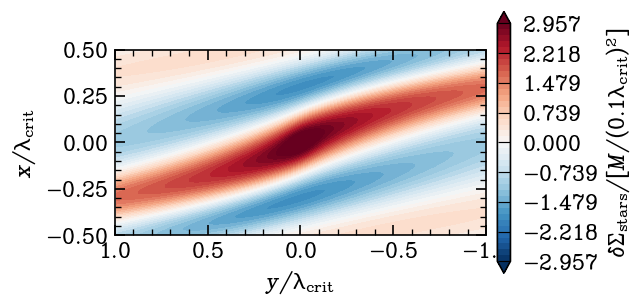

In [14]:
fig, ax = plot_wake_filled_only(
    wake_stars,
    label="stars",
    filename="stars_wake_filled_only_thin_disk.pdf",
)

gas wake plotting range:
    min = -1.7580897538579299
    max = 2.9690390561808817
    color limits = (np.float64(-2.5822849797587484), np.float64(2.5822849797587484))


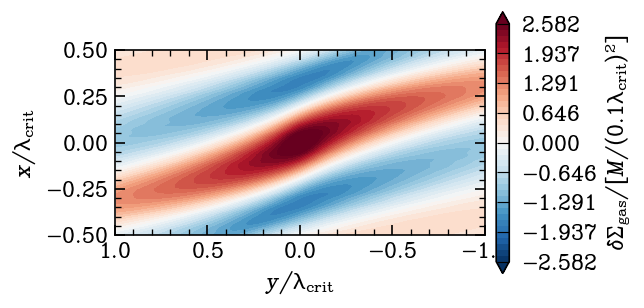

In [15]:
fig, ax = plot_wake_filled_only(
    wake_gas,
    label="gas",
    filename="gas_wake_filled_only_thin_disk.pdf",
)

In [16]:
from matplotlib.gridspec import GridSpec
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import numpy as np
import matplotlib.pyplot as plt


def plot_point_mass_wake_summary(
    wake_stars,
    wake_gas,
    x_grid=None,
    y_grid=None,
    lambda_crit=None,
    cloud_mass=None,
    x_cuts=(0.4, 0.2, 0.0),
    cut_colors=("red", "green", "blue"),
    y_window=(-1.0, 1.0),
    x_window=(-0.5, 0.5),
    color_limits=None,
    color_percentile=99.0,
    n_filled_levels=41,
    cmap="RdBu_r",
    filename=None,
    save=False,
):
    """
    Make a three-panel point-mass wake figure.

    Panels:
        (a) stellar wake contour plot
        (b) gas wake contour plot
        (c) y-cuts at fixed x/lambda_crit

    If color_limits is None, the stellar and gas panels get independent
    symmetric color ranges.
    """

    if x_grid is None:
        x_grid = x_values

    if y_grid is None:
        y_grid = y_values

    if lambda_crit is None:
        lambda_crit = LAMBDA_CRIT

    if cloud_mass is None:
        cloud_mass = CLOUD_MASS

    x_grid = np.asarray(x_grid)
    y_grid = np.asarray(y_grid)

    X_over_lcrit = x_grid / lambda_crit
    Y_over_lcrit = y_grid / lambda_crit

    # Normalize to M / (0.1 lambda_crit)^2 units
    Z_stars = np.asarray(wake_stars) * (0.1 * lambda_crit) ** 2 / cloud_mass
    Z_gas = np.asarray(wake_gas) * (0.1 * lambda_crit) ** 2 / cloud_mass

    expected_shape = (len(X_over_lcrit), len(Y_over_lcrit))

    if Z_stars.shape != expected_shape:
        raise ValueError(
            f"wake_stars has shape {Z_stars.shape}, expected {expected_shape}."
        )

    if Z_gas.shape != expected_shape:
        raise ValueError(
            f"wake_gas has shape {Z_gas.shape}, expected {expected_shape}."
        )

    # Window masks
    mask_x = (X_over_lcrit >= x_window[0]) & (X_over_lcrit <= x_window[1])
    mask_y = (Y_over_lcrit >= y_window[0]) & (Y_over_lcrit <= y_window[1])

    if not np.any(mask_x):
        raise ValueError(f"No x-grid points inside x_window={x_window}.")

    if not np.any(mask_y):
        raise ValueError(f"No y-grid points inside y_window={y_window}.")

    Xc = X_over_lcrit[mask_x]
    Yc = Y_over_lcrit[mask_y]

    Zs_c = Z_stars[np.ix_(mask_x, mask_y)]
    Zg_c = Z_gas[np.ix_(mask_x, mask_y)]

    def get_panel_color_range(Zc, panel_name):
        """
        Get symmetric color limits for one panel.

        color_limits options:
            None:
                independent range for each panel
            scalar:
                same symmetric range for both panels
            dict:
                e.g. {"stars": 3.0, "gas": 1.5}
                or   {"stars": (-3, 3), "gas": (-1.5, 1.5)}
            tuple/list:
                same explicit (vmin, vmax) for both panels
        """

        if color_limits is None:
            vlim = np.nanpercentile(np.abs(Zc), color_percentile)

            if not np.isfinite(vlim) or vlim == 0.0:
                vlim = max(np.nanmax(np.abs(Zc)), 1.0)

            return -vlim, vlim

        if isinstance(color_limits, dict):
            lim = color_limits[panel_name]

            if np.isscalar(lim):
                vlim = abs(float(lim))
                return -vlim, vlim

            return lim

        if np.isscalar(color_limits):
            vlim = abs(float(color_limits))
            return -vlim, vlim

        return color_limits

    # -----------------------------
    # Figure
    # -----------------------------
    fig = plt.figure(figsize=(5.4, 7.0))

    gs = GridSpec(
        3,
        2,
        width_ratios=[1.0, 0.035],
        height_ratios=[1.0, 1.0, 2.0],
        hspace=0.08,
        wspace=0.08,
        figure=fig,
    )

    ax_s = fig.add_subplot(gs[0, 0])
    ax_g = fig.add_subplot(gs[1, 0], sharex=ax_s, sharey=ax_s)
    ax_cut = fig.add_subplot(gs[2, 0], sharex=ax_s)

    cax_s = fig.add_subplot(gs[0, 1])
    cax_g = fig.add_subplot(gs[1, 1])

    # -----------------------------
    # Contour panels
    # -----------------------------
    contour_specs = [
        (ax_s, cax_s, Zs_c, r"(a)", r"\rm s", "stars"),
        (ax_g, cax_g, Zg_c, r"(b)", r"\rm g", "gas"),
    ]

    for ax, cax, Zc, panel_label, component_tex, panel_name in contour_specs:

        # Independent color range for each contour panel
        vmin, vmax = get_panel_color_range(Zc, panel_name)

        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
        levels = np.linspace(vmin, vmax, n_filled_levels)

        cf = ax.contourf(
            Yc,
            Xc,
            Zc,
            levels=levels,
            cmap=cmap,
            norm=norm,
            extend="both",
        )

        ax.set_xlim(y_window[1], y_window[0])
        ax.set_ylim(x_window[0], x_window[1])
        ax.set_aspect("equal", adjustable="box")

        ax.set_ylabel(r"$x/\lambda_{\rm crit}$")

        ax.text(
            0.03,
            0.97,
            panel_label,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=14,
        )

        

        cbar = fig.colorbar(cf, cax=cax)

        # Robust two-decimal colorbar labels
        cbar.formatter = FormatStrFormatter("%.2f")
        cbar.update_ticks()

        cbar.set_label(
            rf"$\delta\Sigma_{{{component_tex}}}/[M/(0.1\lambda_{{\rm crit}})^2]$"
        )
        cbar.ax.tick_params(direction="in")

    plt.setp(ax_s.get_xticklabels(), visible=False)
    plt.setp(ax_g.get_xticklabels(), visible=False)

    # -----------------------------
    # Cut panel
    # -----------------------------
    for x_cut, color in zip(x_cuts, cut_colors):

        ix = np.argmin(np.abs(X_over_lcrit - x_cut))

        y_cut = Y_over_lcrit[mask_y]
        stars_cut = Z_stars[ix, mask_y]
        gas_cut = Z_gas[ix, mask_y]

        ax_cut.plot(
            y_cut,
            stars_cut,
            color=color,
            ls="solid",
            lw=1.4,
        )

        ax_cut.plot(
            y_cut,
            gas_cut,
            color=color,
            ls="dashed",
            lw=1.4,
        )

    ax_cut.axhline(0.0, color="black", lw=0.6)

    ax_cut.set_xlim(y_window[1], y_window[0])
    ax_cut.set_xlabel(r"$y/\lambda_{\rm crit}$")
    ax_cut.set_ylabel(
        r"$\delta\Sigma_i/[M/(0.1\lambda_{\rm crit})^2]$"
    )

    ax_cut.text(
        0.03,
        0.97,
        r"(c)",
        transform=ax_cut.transAxes,
        ha="left",
        va="top",
        fontsize=14,
    )

    ax_cut.set_xticks([1.0, 0.5, 0.0, -0.5, -1.0])
    ax_cut.xaxis.set_minor_locator(MultipleLocator(0.1))
    ax_cut.yaxis.set_minor_locator(MultipleLocator(1.0))

    ax_cut.tick_params(
        which="major",
        direction="in",
        top=True,
        right=True,
        length=6.0,
        width=1.0,
    )

    ax_cut.tick_params(
        which="minor",
        direction="in",
        top=True,
        right=True,
        length=3.5,
        width=0.8,
    )

    # Component legend
    component_handles = [
        Line2D([0], [0], color="black", lw=1.6, ls="solid", label="stars"),
        Line2D([0], [0], color="black", lw=1.6, ls="dashed", label="gas"),
    ]

    legend_component = ax_cut.legend(
        handles=component_handles,
        loc="upper right",
        frameon=False,
    )

    ax_cut.add_artist(legend_component)

    # Colored x-cut labels
    x_text = 0.1
    y0 = 0.7
    dy = 0.08

    for n, (x_cut, color) in enumerate(zip(x_cuts, cut_colors)):
        ax_cut.text(
            x_text,
            y0 + dy * n,
            rf"$x/\lambda_{{\rm crit}} = {x_cut:.1f}$",
            color=color,
            transform=ax_cut.transAxes,
            ha="left",
            va="top",
        )

    # ax_cut.set_ylim(-10, 10)

    fig.subplots_adjust(
        left=0.16,
        right=0.90,
        bottom=0.08,
        top=0.98,
    )

    # Make the bottom x-axis physically align with the contour-panel x-axes.
    # This is useful because the contour panels use aspect="equal".
    fig.canvas.draw()
    pos_s = ax_s.get_position()
    pos_cut = ax_cut.get_position()
    ax_cut.set_position(
        [pos_s.x0, pos_cut.y0, pos_s.width, pos_cut.height]
    )

    if save and filename is not None:
        fig.savefig(filename, bbox_inches="tight",dpi = 600)

    return fig, (ax_s, ax_g, ax_cut)

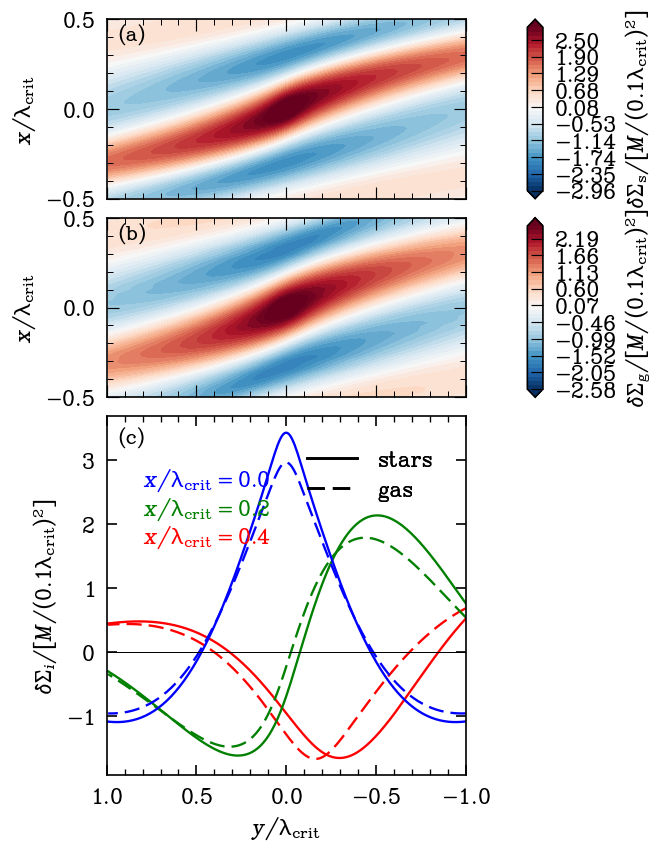

In [17]:
fig, axes = plot_point_mass_wake_summary(
    wake_stars,
    wake_gas,
    x_cuts=(0.4, 0.2, 0.0),
    color_limits=None,
    filename="./Figures/point_mass_wake_summary_thin_disk.png",
    save=True,
    n_filled_levels=40
)

plt.show()